<a href="https://colab.research.google.com/github/andreagrioni/Tutorials/blob/master/mirna_binding_model_interpetation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Interpatation

This notebook provides tools for the interpretation of the network predicting
micro RNA binding sites.

The notebook is an implementation of the process described in the blog [Visualizing Keras CNN attention: Grad-CAM Class Activation Maps](https://www.machinecurve.com/index.php/2019/11/28/visualizing-keras-cnn-attention-grad-cam-class-activation-maps/)

## Load model and datasets

First, it will be required to download the model and toy dataset.

In [1]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


## Copy project directory to local instance

In [0]:
!cp -r '/gdrive/My Drive/datasets/mirna_binding' ./

## Keras-vis: model interpretation tools

Download and install the most recent version of Keras-vis, a set of tools to
perform model interpretation.

Visit [keras-vis](https://github.com/raghakot/keras-vis) for more information.

In [3]:
# install package with pip
pip install https://github.com/raghakot/keras-vis/archive/master.zip

     | 66.2MB 93.3MB/s
  Created wheel for keras-vis: filename=keras_vis-0.5.0-py2.py3-none-any.whl size=30855 sha256=0abc9521c547f446ee839df7595b4654903ecb9a1fc3911d5eff77e964defa8b
  Stored in directory: /tmp/pip-ephem-wheel-cache-xhevfmsk/wheels/7e/91/e5/9fdb0f2f5fa5d9f402c6fbfaf015aadbe3dba024ede6532727
Successfully built keras-vis
  Found existing installation: keras-vis 0.4.1
    Uninstalling keras-vis-0.4.1:
      Successfully uninstalled keras-vis-0.4.1


# Load toy Dataset

Any prediction requires samples.

In [0]:
import joblib

data_pos, data_neg = joblib.load('mirna_binding/data/model_interpretation.joblib')
matrix_pos, label_pos = data_pos
matrix_neg, label_neg = data_neg

# Import trained model

This block of code will import the Keras trained model.

In [3]:
import tensorflow as tf 
source_model = tf.keras.models.load_model('mirna_binding/models/23.0.50.10.iterative_bc_10k.h5')
source_model.summary()

Model: "arch_00b"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
main_input (InputLayer)      [(None, 50, 20, 1)]       0         
_________________________________________________________________
conv_1 (Conv2D)              (None, 50, 20, 32)        320       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 50, 20, 32)        0         
_________________________________________________________________
batch_normalization (BatchNo (None, 50, 20, 32)        128       
_________________________________________________________________
Max_1 (MaxPooling2D)         (None, 25, 10, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 25, 10, 32)        0         
_________________________________________________________________
conv_2 (Conv2D)              (None, 25, 10, 64)        184

In [5]:
len(data)

2

## Prediction of toy dataset

In [0]:
predictions_pos = source_model.predict(matrix_pos)
predictions_neg = source_model.predict(matrix_neg)

## Compatibility between Keras versions.

The model was trained using tensorflow.keras, while the Keras-vis model is using
Keras. Therefore, running any Keras-vis tool will return `ValueError` since the 
tools are looking for Keras Layers from `import keras`, whilst the model uses
`from tensorflow.keras import keras`. The simplest way to fix the error is to
build a new identical model with Keras and then transfer weights from the trained original model to the new one.

## Build the new identical model (clone)

In [8]:
import keras
from keras.layers import BatchNormalization, LeakyReLU, Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras import Model
from keras import backend as K
from keras.callbacks import EarlyStopping

Using TensorFlow backend.


## Define architecture

In [0]:
def make_arch_00b():
    main_input = Input(shape=(50,20,1), dtype='float32', name='main_input')

    x = Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        data_format="channels_last",
        name="conv_1")(main_input)    
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='Max_1')(x)
    x = Dropout(rate = 0.25)(x)


    x = Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        data_format="channels_last",
        name="conv_2")(x)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='Max_2')(x)
    x = Dropout(rate = 0.25)(x)

    x = Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        data_format="channels_last",
        name="conv_3")(x)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='Max_3')(x)
    x = Dropout(rate = 0.25)(x)


    conv_flat = Flatten(name='2d_matrix')(x)

    x = Dense(128, name='dense_1')(conv_flat)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)
    x = Dropout(rate = 0.25)(x)

    x = Dense(64, name='dense_2')(x)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)
    x = Dropout(rate = 0.25)(x)

    x = Dense(32, name='dense_3')(x)
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)
    x = Dropout(rate = 0.25)(x)

    main_output = Dense(1, activation='sigmoid', name='main_output')(x)

    model = Model(inputs=[main_input], outputs=[main_output], name='arch_00b')
    
    return model

## Create model

In [100]:
clone = make_arch_00b()
clone.summary()

Model: "arch_00b"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
main_input (InputLayer)      (None, 50, 20, 1)         0         
_________________________________________________________________
conv_1 (Conv2D)              (None, 50, 20, 32)        320       
_________________________________________________________________
leaky_re_lu_49 (LeakyReLU)   (None, 50, 20, 32)        0         
_________________________________________________________________
batch_normalization_49 (Batc (None, 50, 20, 32)        128       
_________________________________________________________________
Max_1 (MaxPooling2D)         (None, 25, 10, 32)        0         
_________________________________________________________________
dropout_49 (Dropout)         (None, 25, 10, 32)        0         
_________________________________________________________________
conv_2 (Conv2D)              (None, 25, 10, 64)        184

## Extract weights from source model

In [0]:
source_model_weights = source_model.get_weights()

## Transfer weights to the new model

In [0]:
clone.set_weights(source_model_weights)

## Compile the new model

Since we created a new model, we will need first to compile it.

In [0]:
clone.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    )

# Model interpretation

Keras-vis is a high-level API allowing the implementation of different model interpretation techniques. It is a toolkit that can be integrated with your Keras models, and used for visualization.

Overall, Keras-vis provides three types of visualizations:

- Activation Maximization, which essentially generates a perfect image of a particular class for a trained model.
- Saliency Maps, which – given some input image – tell you something about the importance of each pixel for generating the class decision, hence visualizing where the model looks at when deciding.
- Class Activation Maps, and especially **Grad-CAM** class activation maps, which generate heatmaps at the convolutional level rather than the dense neural layer level, taking into account more spatial details.

This notebook focuses on gradient-weighted class activation maps, or Grad-CAM.

## Import the required tools from Keras-vis

In [0]:
# import keras
# #from tensorflow import keras as keras
from vis.visualization import visualize_cam, overlay
from vis.utils import utils
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from keras import activations

## Define which layer we want to visualize

The model is defined by 3 convolutional layers followed by fully connected layers. 

Each of the convolutional layers is named as 'conv_1', 'conv_2', 'conv_3'. 

We will visualize the last layer, 'main_output'.

In [0]:
replace_layer = 'dense_3'
layer_index = utils.find_layer_idx(clone,replace_layer)

In [0]:
# # Swap softmax with linear
# from keras.utils import CustomObjectScope
# from keras.initializers import glorot_uniform
# from tensorflow.keras.models import load_model
# from tensorflow import keras as keras
clone.layers[layer_index].activation = activations.linear
clone = utils.apply_modifications(clone)

## Run prediciton to visualize Grad-CAM of conv_3 layer

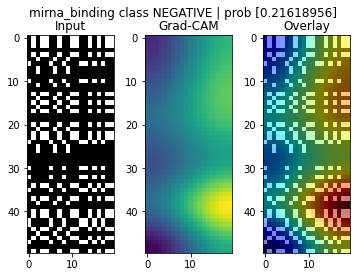

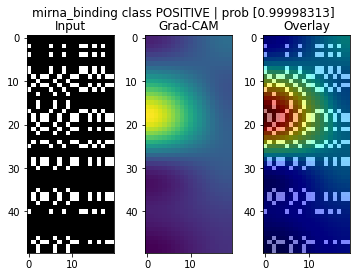

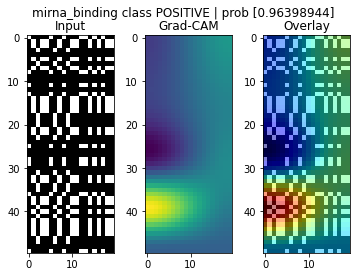

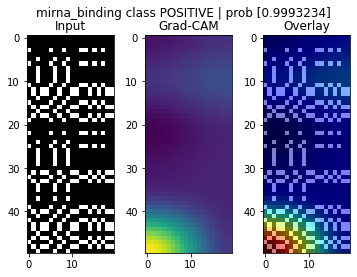

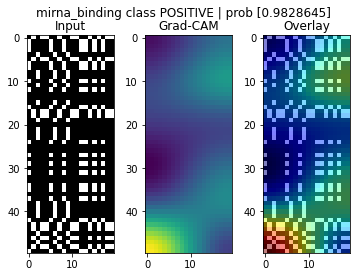

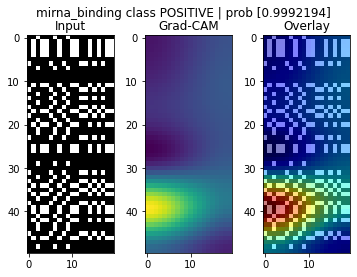

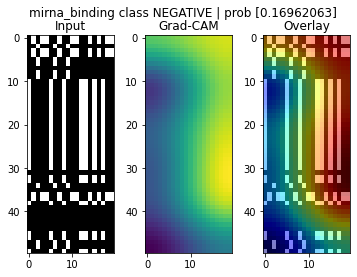

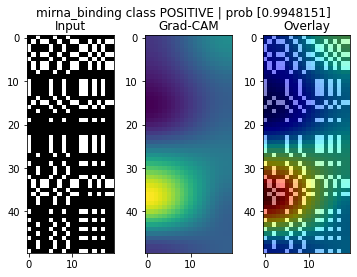

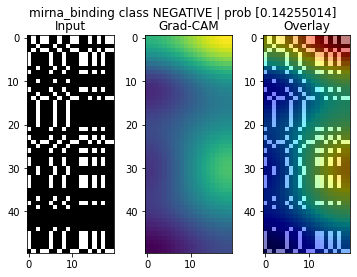

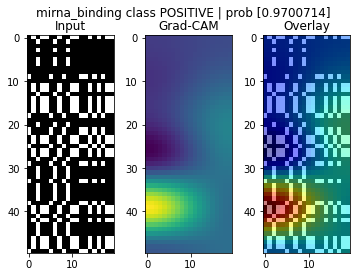

In [105]:
outfolder = '/gdrive/My Drive/datasets/mirna_binding/img/'
tag = replace_layer
# Visualize
input_class = 1
for index, input_image in enumerate(matrix_pos):
  # Get input
  image_pred_score = predictions_pos[index]
  if image_pred_score > 0.5:
    predicted_class = "POSITIVE"
  else:
    predicted_class = "NEGATIVE"
  # Matplotlib preparations
  fig, axes = plt.subplots(1, 3)
  # Generate visualization
  visualization = visualize_cam(clone, layer_index, filter_indices=input_class, seed_input=input_image)
  axes[0].imshow(input_image[..., 0], cmap='gray') 
  axes[0].set_title('Input')
  axes[1].imshow(visualization)
  axes[1].set_title('Grad-CAM')
  heatmap = np.uint8(cm.jet(visualization)[..., :3] * 255)
  original = np.uint8(cm.gray(input_image[..., 0])[..., :3] * 255)
  axes[2].imshow(overlay(heatmap, original))
  axes[2].set_title('Overlay')
  fig.suptitle(f'mirna_binding class {predicted_class} | prob {image_pred_score}')
  plt.savefig(f'{outfolder}/{index}.{predicted_class}.{tag}.png', dpi=300)
  #plt.show()